In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from datetime import datetime
from textblob import TextBlob
from wordcloud import WordCloud
from collections import Counter
from nltk.corpus import stopwords
import string


In [3]:
file_path = 'HR Analytics Assignment.csv'
df = pd.read_csv(file_path)

In [4]:
rating_map = {
    "Very Dissatisfied": 1,
    "Dissatisfied": 2,
    "Neutral": 3,
    "Satisfied": 4,
    "Very Satisfied": 5
}
rating_cols = ['Overall Rating', 'Career Growth', 'Compensation and Benefits', 'Work-life Balance']
for col in rating_cols:
    df[col] = df[col].map(rating_map)


In [5]:
df.describe()

,Overall Rating,Career Growth,Compensation and Benefits,Work-life Balance
count,25866.000000,25866.000000,25866.000000,25866.00000
mean,3.707840,3.641576,3.049331,3.67784
std,1.256557,1.325245,1.333548,1.28195
min,1.000000,1.000000,1.000000,1.00000
25%,3.000000,3.000000,2.000000,3.00000
50%,4.000000,4.000000,3.000000,4.00000
75%,5.000000,5.000000,4.000000,5.00000
max,5.000000,5.000000,5.000000,5.00000


In [6]:
df.isnull().sum()

EmpID                         0
Location                     35
Gender                       35
Level                        35
Date Of Joining               0
Overall Rating                0
Career Growth                 0
Compensation and Benefits     0
Work-life Balance             0
Comments                     59
dtype: int64

In [8]:
df['Date Of Joining'] = pd.to_datetime(df['Date Of Joining'])

C:\Users\Ann S Vettoor\AppData\Local\Temp\ipykernel_11736\2679818189.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date Of Joining'] = pd.to_datetime(df['Date Of Joining'])


In [9]:
df.head()

,EmpID,Location,Gender,Level,Date Of Joining,Overall Rating,Career Growth,Compensation and Benefits,Work-life Balance,Comments
0,a80b49x693,LocD,Men,Middle,2019-05-10,4,4,3,4,It's a full package of privileged engagement.
1,a81b94x601,Remote,Men,Middle,2006-06-05,1,3,1,5,Everything is good
2,a81b10x636,LocC,Women,Middle,2022-06-02,5,5,5,5,Notice period
3,a80b73x624,LocA,Women,Junior,2022-05-10,4,4,3,3,"Attrition, people join and left very frequently."
4,a82b26x611,LocD,Women,Junior,2006-02-18,1,3,4,3,I worked in GE.\n All managers are totally unf...


In [10]:
df_missing_percent = df.isnull().sum()/len(df)
df_missing_percent

EmpID                        0.000000
Location                     0.001353
Gender                       0.001353
Level                        0.001353
Date Of Joining              0.000000
Overall Rating               0.000000
Career Growth                0.000000
Compensation and Benefits    0.000000
Work-life Balance            0.000000
Comments                     0.002281
dtype: float64

Text(0, 0.5, 'Overall Rating')

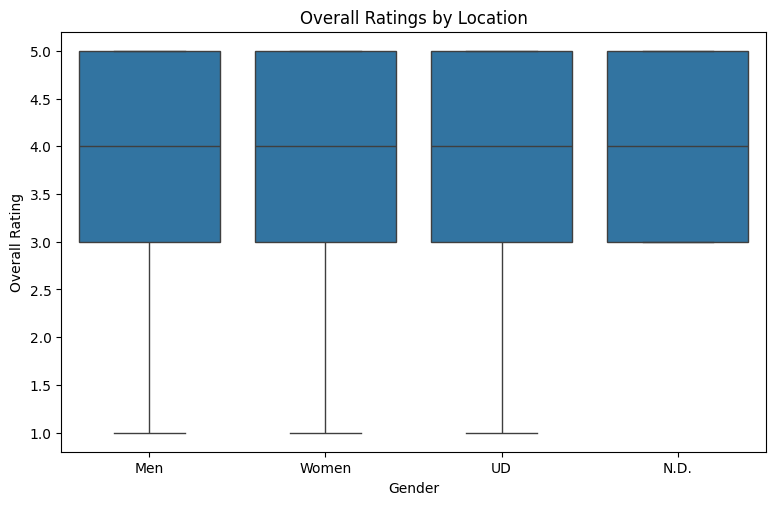

In [ ]:
plt.figure(figsize=(20, 12))
plt.subplot(2, 2, 1)
sns.boxplot(data=df, x='Location', y='Overall Rating')
plt.title('Overall Ratings by Location')
plt.xlabel('Location')
plt.ylabel('Overall Rating')

Text(0, 0.5, 'Career Growth')

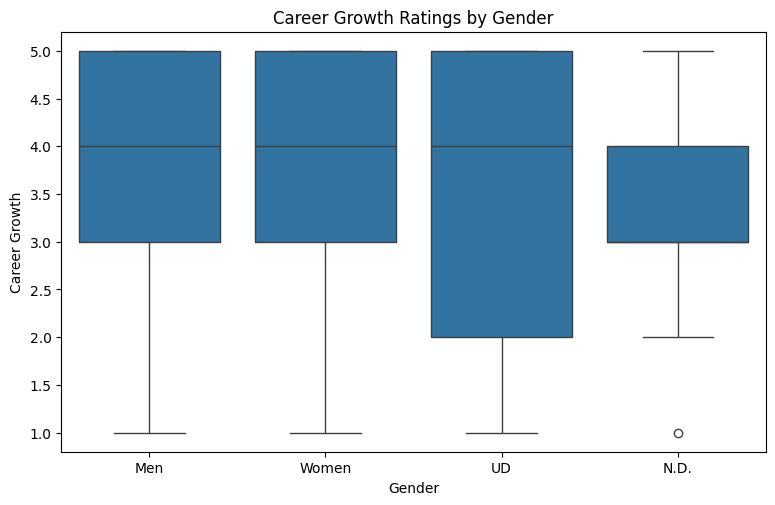

In [12]:
plt.figure(figsize=(20, 12))
plt.subplot(2, 2, 2)
sns.boxplot(data=df, x='Gender', y='Career Growth')
plt.title('Career Growth Ratings by Gender')
plt.xlabel('Gender')
plt.ylabel('Career Growth')

In [22]:
df['Level'] = df['Level'].str.strip().str.title() 


C:\Users\Ann S Vettoor\AppData\Local\Temp\ipykernel_11736\1380760335.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x='Level', y='Work-life Balance', ci=None, estimator=sum)


Text(0, 0.5, 'Sum of Work-Life Balance Ratings')

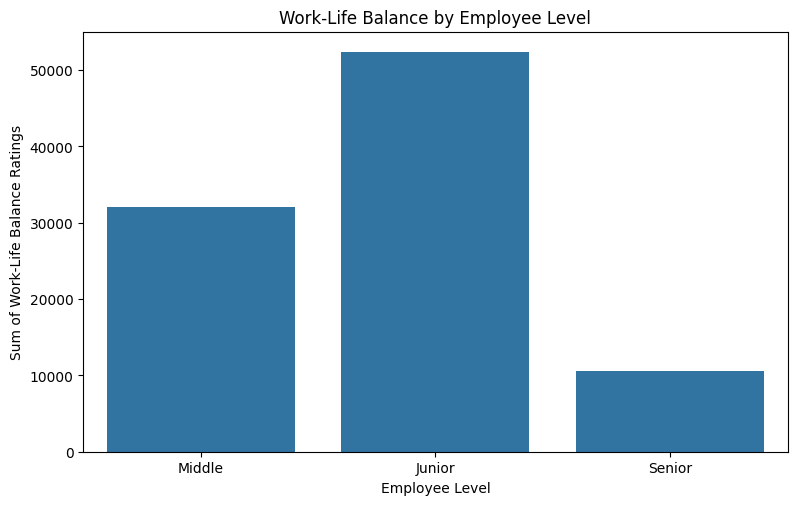

In [23]:

plt.figure(figsize=(20, 12))
plt.subplot(2, 2, 3)
sns.barplot(data=df, x='Level', y='Work-life Balance', ci=None, estimator=sum)
plt.title('Work-Life Balance by Employee Level')
plt.xlabel('Employee Level')
plt.ylabel('Sum of Work-Life Balance Ratings') 

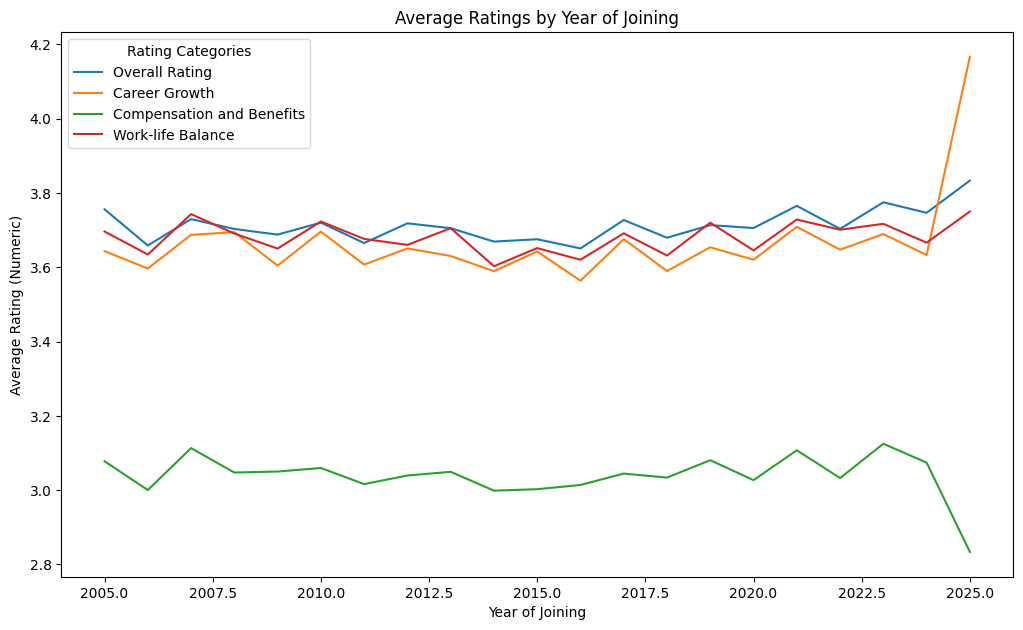

In [14]:
plt.figure(figsize=(20, 12))
df['Year Of Joining'] = df['Date Of Joining'].dt.year
yearly_ratings = df.groupby('Year Of Joining')[rating_cols].mean().reset_index()

plt.subplot(2, 2, 4)
for col in rating_cols:
    plt.plot(yearly_ratings['Year Of Joining'], yearly_ratings[col], label=col)
plt.title('Average Ratings by Year of Joining')
plt.xlabel('Year of Joining')
plt.ylabel('Average Rating (Numeric)')
plt.legend(title='Rating Categories')

plt.tight_layout()
plt.show()


In [15]:
pivot_table = df.pivot_table(values='Overall Rating', index='Location', columns='Gender', aggfunc='mean')
print("Pivot Table: Overall Ratings by Location and Gender")
print(pivot_table)
# pivot_table.to_csv('pivot_table_overall_ratings.csv')

Pivot Table: Overall Ratings by Location and Gender
Gender         Men      N.D.        UD     Women
Location                                        
LocA      3.542422  5.000000  3.484848  3.800863
LocB      3.653037  3.333333  3.593750  3.778887
LocC      3.638404       NaN  3.564103  3.800958
LocD      3.605988  3.666667  3.618557  3.835655
LocE      3.636728  5.000000  3.330097  3.765615
LocF      3.642983  4.250000  3.698113  3.815041
LocG      3.660296       NaN  3.484536  3.840195
Remote    3.693642       NaN  3.572650  3.810773


In [16]:
correlation_matrix = df[['Overall Rating', 'Career Growth', 'Compensation and Benefits', 'Work-life Balance']].corr()
correlation_matrix

,Overall Rating,Career Growth,Compensation and Benefits,Work-life Balance
Overall Rating,1.000000,0.701910,0.625932,0.672094
Career Growth,0.701910,1.000000,0.695075,0.761828
Compensation and Benefits,0.625932,0.695075,1.000000,0.654157
Work-life Balance,0.672094,0.761828,0.654157,1.000000


In [17]:
highest_correlation = correlation_matrix['Overall Rating'][1:].idxmax()
highest_value = correlation_matrix['Overall Rating'][1:].max()

print("Correlation Matrix:")
print(correlation_matrix)
summary_data = {
    'Factor': ['Career Growth', 'Compensation and Benefits', 'Work-life Balance'],
    'Correlation with Overall Rating': correlation_matrix['Overall Rating'][1:].values
}
summary_df = pd.DataFrame(summary_data)
summary_file_path = 'correlation_summary.csv'
# summary_df.to_csv(summary_file_path, index=False)

Correlation Matrix:
                           Overall Rating  Career Growth  \
Overall Rating                   1.000000       0.701910   
Career Growth                    0.701910       1.000000   
Compensation and Benefits        0.625932       0.695075   
Work-life Balance                0.672094       0.761828   

                           Compensation and Benefits  Work-life Balance  
Overall Rating                              0.625932           0.672094  
Career Growth                               0.695075           0.761828  
Compensation and Benefits                   1.000000           0.654157  
Work-life Balance                           0.654157           1.000000  


In [24]:
df['Date Of Joining'] = pd.to_datetime(df['Date Of Joining'], format='%d-%b-%y', errors='coerce')
df['Duration'] = (datetime.now() - df['Date Of Joining']).dt.days / 365.25
df['Class'] = df['Tenure (Years)'].apply(
    lambda x: 'High Tenured (15+ Years)' if x >= 15 else ('Covid Joiner(2020+)' if x <= 3 else 'Others')
)
# dissatisfaction_levels = [1,2]

def is_dissatisfied(overall_rating):
    return overall_rating in [1,2]

df['Very Dissatisfied'] = df['Overall Rating'].apply(is_dissatisfied)

dissatisfaction_summary = df.groupby('Class').agg(
    Total_Associates=('EmpID', 'count'),
    Dissatisfied_Associates=('Very Dissatisfied', 'sum'),
    Dissatisfaction_Rate=('Very Dissatisfied', 'mean')
).reset_index()

dissatisfaction_summary['Dissatisfaction_Rate'] = dissatisfaction_summary['Dissatisfaction_Rate'] * 100

# output_file = 'Dissatisfaction_By_Tenure.csv'
# dissatisfaction_summary.to_csv(output_file, index=False)
dissatisfaction_summary


,Class,Total_Associates,Dissatisfied_Associates,Dissatisfaction_Rate
0,Covid Joiner(2020+),3763,610,16.210470
1,High Tenured (15+ Years),6532,1097,16.794244
2,Others,15571,2642,16.967439


In [25]:
df['Comments'] = df['Comments'].astype(str)
def sentimentanalysis(comment):
    blob = TextBlob(comment)
    return blob.sentiment.polarity
df['Sentiment Polarity'] = df['Comments'].apply(sentimentanalysis)
df['Categorry of sentiment'] = df['Sentiment Polarity'].apply(
    lambda x: 'Positive' if x > 0 else ('Negative' if x < 0 else 'Neutral')
)
sentiment_summary = df['Categorry of sentiment'].value_counts().reset_index()
sentiment_summary.columns = ['Sentiment', 'Count']
output_file = "sentiment_summary.csv"
# sentiment_summary.to_csv(output_file, index=False)

# Print the sentiment summary
print(sentiment_summary)

  Sentiment  Count
0   Neutral  13174
1  Positive  10198
2  Negative   2494


In [102]:
stop_words = set(stopwords.words('english'))
def preprocessing(text):
    text = text.lower() 
    text = text.translate(str.maketrans('', '', string.punctuation)) 
    words = text.split()
    words = [i for i in words if i not in stop_words]  
    return words

df['Processed_Comments'] = df['Comments'].apply(preprocessing)

In [103]:
df['Processed_Comments'].head()

0              [full, package, privileged, engagement]
1                                   [everything, good]
2                                     [notice, period]
3          [attrition, people, join, left, frequently]
4    [worked, ge, managers, totally, unfair, dont, ...
Name: Processed_Comments, dtype: object

In [104]:
all_words = [j for comment in df['Processed_Comments'] for j in comment]
len(all_words)

125433

In [105]:

theme_counts = Counter(all_words)
top_10_themes = theme_counts.most_common(10)
top_10_themes

[('work', 7885),
 ('good', 7268),
 ('company', 2726),
 ('balance', 2712),
 ('life', 2646),
 ('culture', 2640),
 ('0', 2351),
 ('nothing', 2077),
 ('job', 1618),
 ('companyx', 1612)]

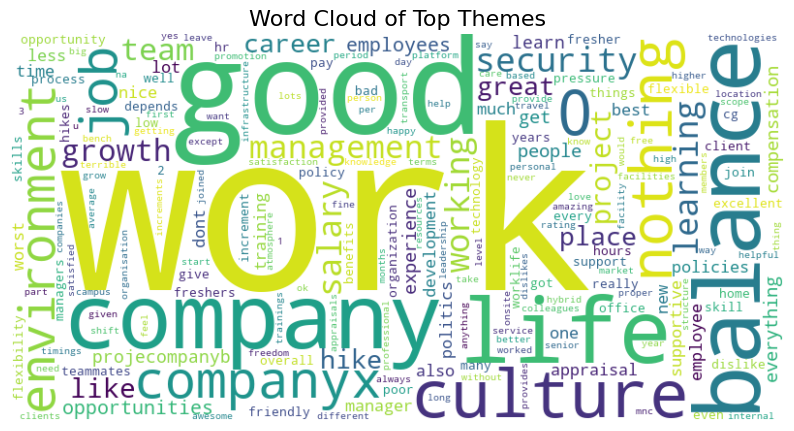

Top 10 Themes:
work: 7885
good: 7268
company: 2726
balance: 2712
life: 2646
culture: 2640
0: 2351
nothing: 2077
job: 1618
companyx: 1612


In [106]:

wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(theme_counts)

plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud of Top Themes", fontsize=16)
plt.show()

print("Top 10 Themes:")
for theme, count in top_10_themes:
    print(f"{theme}: {count}")
